In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

In [6]:
df

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32419,U32420,30,Female,High School,Employed,Salesperson,4266.87,1510.82,273669.70,Yes,Car,498400.74,120,6227.54,8.68,1.46,434,5.34,Europe,2024-02-25
32420,U32421,51,Female,Master,Employed,Student,5725.78,4965.02,17247.57,Yes,Home,83602.57,12,7605.13,16.50,1.33,453,0.25,North America,2025-06-06
32421,U32422,18,Female,Bachelor,Self-employed,Doctor,3282.38,2243.77,22081.21,No,NaN,0.00,0,0.00,0.00,0.00,391,0.56,Other,2025-07-20
32422,U32423,36,Other,High School,Self-employed,Accountant,5035.99,4054.32,524039.88,No,NaN,0.00,0,0.00,0.00,0.00,596,8.67,Asia,2022-06-07


In [3]:
# ==========================================
# ส่วนที่ 1: Methodology - Data Preparation & Missing Data Simulation
# ==========================================

# ตั้งค่า Style สำหรับกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

print("--- 3.1 & 3.2 Data Preparation, Selection, and Preprocessing ---")

# 1. Drop Noise Columns (ตัดคอลัมน์ที่ไม่เกี่ยวกับการทำนายทิ้ง)
cols_to_drop = ['user_id', 'record_date']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).copy()

target_col = 'education_level' 
print(f"Target Variable: {target_col}")

# 2. แยกประเภทของตัวแปร
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.drop(target_col).tolist()

# ฟังก์ชันสำหรับจำลองข้อมูลสูญหายแบบสุ่ม (MCAR)
def simulate_missing_data(data, column, missing_rate):
    df_simulated = data.copy()
    n_missing = int(len(data) * missing_rate)
    
    np.random.seed(42) # ล็อก seed เพื่อความโปร่งใสและทำซ้ำได้
    missing_indices = np.random.choice(data.index, n_missing, replace=False)
    
    df_simulated.loc[missing_indices, column] = np.nan
    return df_simulated, missing_indices

--- 3.1 & 3.2 Data Preparation, Selection, and Preprocessing ---
Target Variable: education_level


/var/folders/f3/btxgh9_n0pxcpl5pr8h1cs1m0000gn/T/ipykernel_20350/496428234.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.drop(target_col).tolist()


In [13]:
df_clean[target_col].value_counts()

education_level
Bachelor       13038
Master          9673
High School     6456
PhD             1638
Other           1619
Name: count, dtype: int64

In [4]:
# ==========================================
# ส่วนที่ 2: Methodology - Applying Imputation Methods
# ==========================================

missing_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []
dist_data_30_percent = {}

print("\n--- 3.3 & 3.4 Missing Data Simulation and Imputation ---")

# เตรียม Label Encoder สำหรับ Target Variable ก่อน เพื่อเก็บ Mapping ไว้แปลงกลับ
le_target = LabelEncoder()
le_target.fit(df_clean[target_col].dropna())
# สร้าง Dictionary สำหรับแปลง ตัวเลข -> ตัวหนังสือ (Categories)
target_mapping = dict(zip(range(len(le_target.classes_)), le_target.classes_))

for rate in missing_rates:
    print(f"กำลังประมวลผลที่ Missing Rate: {rate*100}%...")
    
    # จำลองข้อมูลสูญหาย
    df_sim, missing_idx = simulate_missing_data(df_clean, target_col, rate)
    y_true = df_clean.loc[missing_idx, target_col] # Ground Truth
    
    # --- วิธีที่ 1: Mode Imputation (Baseline) ---
    mode_imputer = SimpleImputer(strategy='most_frequent')
    df_mode = df_sim.copy()
    df_mode[target_col] = mode_imputer.fit_transform(df_mode[[target_col]]).ravel()
    y_pred_mode = df_mode.loc[missing_idx, target_col]
    
    # ประเมินผล Mode
    acc_mode = accuracy_score(y_true, y_pred_mode)
    f1_mode = f1_score(y_true, y_pred_mode, average='macro')
    
    # --- Data Preprocessing สำหรับ ML Models (KNN & Iterative) ---
    df_ml = df_sim.copy()
    
    # 1. Label Encoding สำหรับ Categorical columns อื่นๆ
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        # เติมค่าว่างด้วย Mode ชั่วคราวเฉพาะตอน fit เพื่อไม่ให้ LabelEncoder พัง (ถ้ามี)
        df_ml[col] = le.fit_transform(df_ml[col].fillna(df_ml[col].mode()[0]))
        
    # แปลง Target column เป็นตัวเลข (เฉพาะค่าที่ไม่ใช่ NaN)
    df_ml[target_col] = df_ml[target_col].map({v: k for k, v in target_mapping.items()})
    
    # 2. Feature Scaling สำหรับ Numerical columns (สำคัญมากสำหรับ KNN)
    scaler = StandardScaler()
    df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])
    
    # --- วิธีที่ 2: KNN Imputation (k=5) ---
    knn_imputer = KNNImputer(n_neighbors=5)
    df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_ml), columns=df_ml.columns, index=df_ml.index)
    
    # ดึงค่าที่ Impute แล้ว, ปัดเศษเป็นจำนวนเต็ม, และแปลงกลับเป็น Categories
    pred_knn_num = np.round(df_knn_imputed.loc[missing_idx, target_col]).astype(int)
    # Clip ค่าเพื่อป้องกันไม่ให้เกินขอบเขตของ Categories
    pred_knn_num = np.clip(pred_knn_num, 0, len(target_mapping) - 1) 
    y_pred_knn = pred_knn_num.map(target_mapping)
    
    acc_knn = accuracy_score(y_true, y_pred_knn)
    f1_knn = f1_score(y_true, y_pred_knn, average='macro')
    
    # --- วิธีที่ 3: Iterative Imputation (Bayesian Ridge) ---
    iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)
    df_iter_imputed = pd.DataFrame(iter_imputer.fit_transform(df_ml), columns=df_ml.columns, index=df_ml.index)
    
    pred_iter_num = np.round(df_iter_imputed.loc[missing_idx, target_col]).astype(int)
    pred_iter_num = np.clip(pred_iter_num, 0, len(target_mapping) - 1)
    y_pred_iter = pred_iter_num.map(target_mapping)
    
    acc_iter = accuracy_score(y_true, y_pred_iter)
    f1_iter = f1_score(y_true, y_pred_iter, average='macro')
    
    # บันทึกผลลัพธ์
    results.append({
        'Missing_Rate_Pct': int(rate * 100),
        'Acc_Mode': acc_mode,
        'Acc_KNN': acc_knn,
        'Acc_Iterative': acc_iter,
        'F1_Mode': f1_mode,
        'F1_KNN': f1_knn,
        'F1_Iterative': f1_iter
    })
    
    # เก็บข้อมูลการกระจายตัว ณ 30% Missing rate
    if rate == 0.3:
        df_knn_final = df_sim.copy()
        df_knn_final.loc[missing_idx, target_col] = y_pred_knn
        df_iter_final = df_sim.copy()
        df_iter_final.loc[missing_idx, target_col] = y_pred_iter
        
        dist_data_30_percent = {
            'Original (Ground Truth)': df_clean[target_col],
            'Mode Imputation': df_mode[target_col],
            'KNN Imputation': df_knn_final[target_col],
            'Iterative Imputation': df_iter_final[target_col]
        }

# แสดงผลลัพธ์แบบตาราง
df_results = pd.DataFrame(results)
print("\n--- 4.1 Imputation Performance Results ---")
display(df_results)


--- 3.3 & 3.4 Missing Data Simulation and Imputation ---
กำลังประมวลผลที่ Missing Rate: 10.0%...
กำลังประมวลผลที่ Missing Rate: 20.0%...
กำลังประมวลผลที่ Missing Rate: 30.0%...
กำลังประมวลผลที่ Missing Rate: 40.0%...
กำลังประมวลผลที่ Missing Rate: 50.0%...

--- 4.1 Imputation Performance Results ---


,Missing_Rate_Pct,Acc_Mode,Acc_KNN,Acc_Iterative,F1_Mode,F1_KNN,F1_Iterative
0,10,0.415484,0.223936,0.195250,0.117411,0.137985,0.065342
1,20,0.408544,0.239358,0.196021,0.116019,0.146894,0.065558
2,30,0.406189,0.238100,0.195435,0.115543,0.147148,0.065394
3,40,0.409284,0.239494,0.195158,0.116168,0.148499,0.065316
4,50,0.407784,0.242043,0.196953,0.115866,0.150577,0.065818


{0: 'Bachelor', 1: 'High School', 2: 'Master', 3: 'Other', 4: 'PhD'}


--- Generating Visualizations for Chapter 4 & 5 ---


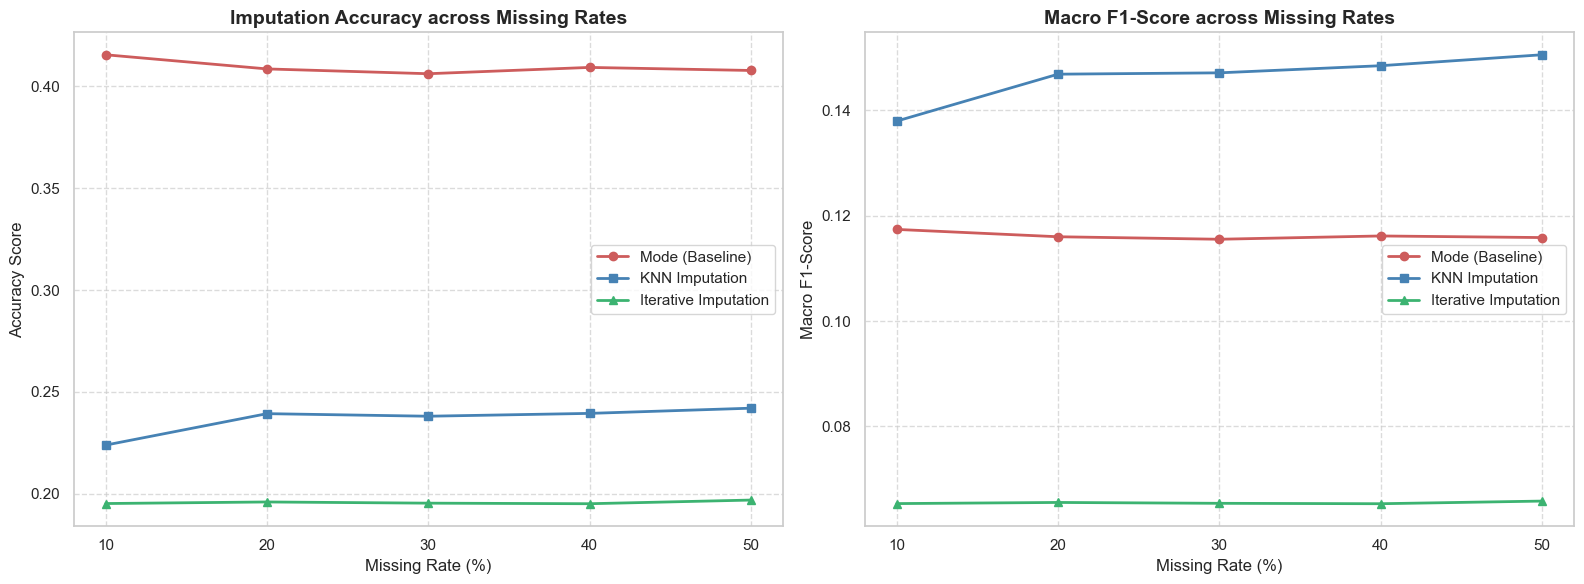

<Figure size 1200x700 with 0 Axes>

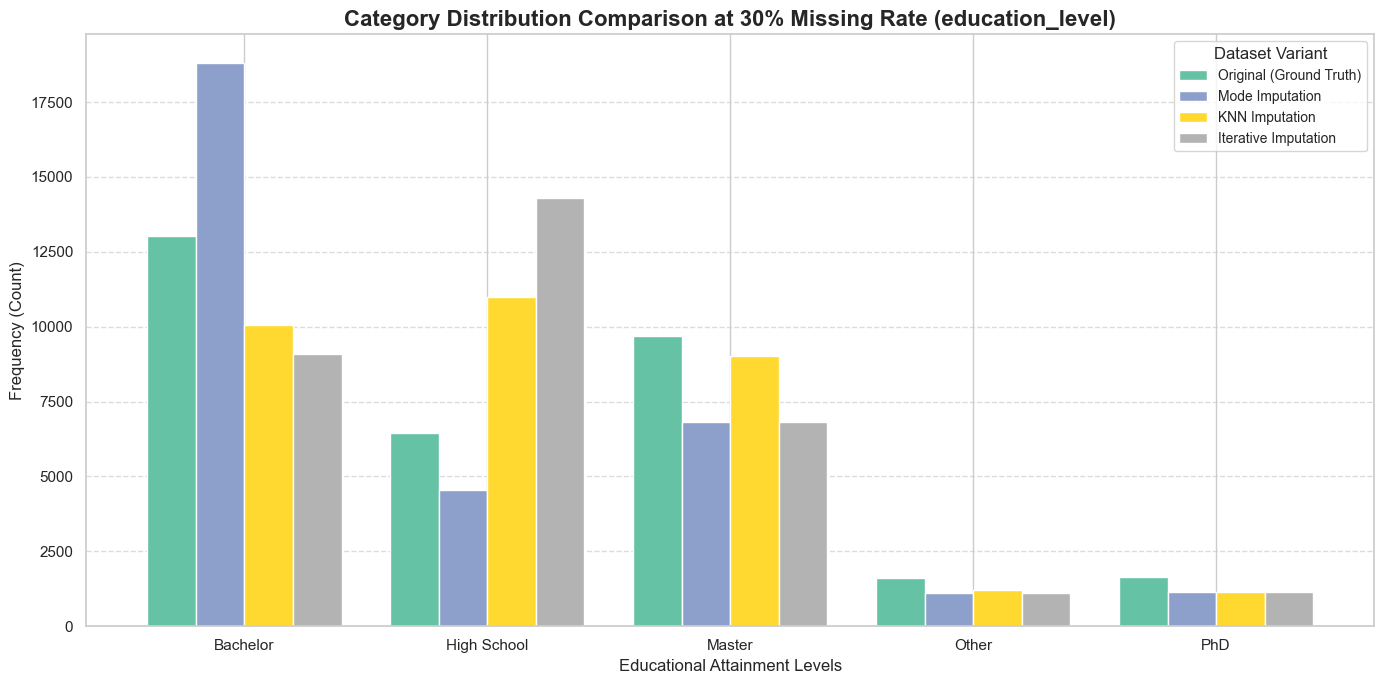


การรันผลเสร็จสมบูรณ์: สามารถคัดลอกตาราง (df_results) และ Save กราฟไปใส่ในบทที่ 4 ได้เลยครับ


In [5]:
# ==========================================
# ส่วนที่ 3: Results - Visualization
# ==========================================
print("\n--- Generating Visualizations for Chapter 4 & 5 ---")

# กราฟที่ 1: เปรียบเทียบ Accuracy และ F1-Score (สร้างเป็น Subplots ซ้ายขวาให้ดูเป็นงานวิจัยชั้นสูง)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1.1 Accuracy Plot
axes[0].plot(df_results['Missing_Rate_Pct'], df_results['Acc_Mode'], marker='o', label='Mode (Baseline)', color='indianred', linewidth=2)
axes[0].plot(df_results['Missing_Rate_Pct'], df_results['Acc_KNN'], marker='s', label='KNN Imputation', color='steelblue', linewidth=2)
axes[0].plot(df_results['Missing_Rate_Pct'], df_results['Acc_Iterative'], marker='^', label='Iterative Imputation', color='mediumseagreen', linewidth=2)
axes[0].set_title('Imputation Accuracy across Missing Rates', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Missing Rate (%)', fontsize=12)
axes[0].set_ylabel('Accuracy Score', fontsize=12)
axes[0].set_xticks(df_results['Missing_Rate_Pct'])
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 1.2 Macro F1-Score Plot
axes[1].plot(df_results['Missing_Rate_Pct'], df_results['F1_Mode'], marker='o', label='Mode (Baseline)', color='indianred', linewidth=2)
axes[1].plot(df_results['Missing_Rate_Pct'], df_results['F1_KNN'], marker='s', label='KNN Imputation', color='steelblue', linewidth=2)
axes[1].plot(df_results['Missing_Rate_Pct'], df_results['F1_Iterative'], marker='^', label='Iterative Imputation', color='mediumseagreen', linewidth=2)
axes[1].set_title('Macro F1-Score across Missing Rates', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Missing Rate (%)', fontsize=12)
axes[1].set_ylabel('Macro F1-Score', fontsize=12)
axes[1].set_xticks(df_results['Missing_Rate_Pct'])
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# กราฟที่ 2: การรักษาการกระจายตัวของข้อมูล (Distribution Preservation) ที่ 30% Missing Rate
plt.figure(figsize=(12, 7))

# สร้าง DataFrame นับความถี่
dist_df = pd.DataFrame({k: v.value_counts() for k, v in dist_data_30_percent.items()}).fillna(0)

# Plot Grouped Bar Chart
ax = dist_df.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='Set2')
plt.title(f'Category Distribution Comparison at 30% Missing Rate ({target_col})', fontsize=16, fontweight='bold')
plt.xlabel('Educational Attainment Levels', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Dataset Variant", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nการรันผลเสร็จสมบูรณ์: สามารถคัดลอกตาราง (df_results) และ Save กราฟไปใส่ในบทที่ 4 ได้เลยครับ")